In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\WIN 10\Desktop\attacks.csv", encoding="cp1252")

In [3]:
df.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-18,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,...,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-18,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-18,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN
3,2018.06.08,08-Jun-18,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,...,2 m shark,"B. Myatt, GSAF",2018.06.08-Arrawarra.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.08,2018.06.08,6300.0,NaN,NaN
4,2018.06.04,04-Jun-18,2018.0,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,...,"Tiger shark, 3m",A .Kipper,2018.06.04-Ramos.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.04,2018.06.04,6299.0,NaN,NaN


In [4]:
df.shape

(25723, 24)

In [5]:
df.columns

Index(['Case Number', 'Date', 'Year', 'Type', 'Country', 'Area', 'Location',
       'Activity', 'Name', 'Sex ', 'Age', 'Injury', 'Fatal (Y/N)', 'Time',
       'Species ', 'Investigator or Source', 'pdf', 'href formula', 'href',
       'Case Number.1', 'Case Number.2', 'original order', 'Unnamed: 22',
       'Unnamed: 23'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25723 entries, 0 to 25722
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case Number             6302 non-null   str    
 1   Date                    6302 non-null   str    
 2   Year                    6300 non-null   float64
 3   Type                    6298 non-null   str    
 4   Country                 6252 non-null   str    
 5   Area                    5847 non-null   str    
 6   Location                5762 non-null   str    
 7   Activity                5758 non-null   str    
 8   Name                    6092 non-null   str    
 9   Sex                     5737 non-null   str    
 10  Age                     3471 non-null   str    
 11  Injury                  6274 non-null   str    
 12  Fatal (Y/N)             5763 non-null   str    
 13  Time                    2948 non-null   str    
 14  Species                 3464 non-null   str    
 

In [7]:
df.describe()

,Year,original order
count,6300.000000,6302.000000
mean,1927.272381,3152.499683
std,281.116308,1819.375481
min,0.000000,2.000000
25%,1942.000000,1577.250000
50%,1977.000000,3152.500000
75%,2005.000000,4727.750000
max,2018.000000,6303.000000


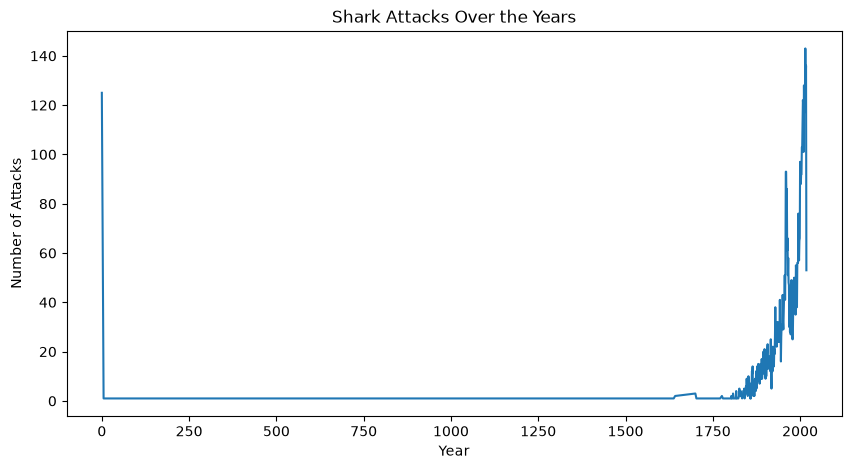

In [8]:
yearly_attacks = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(yearly_attacks.index, yearly_attacks.values)

plt.title("Shark Attacks Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.show()

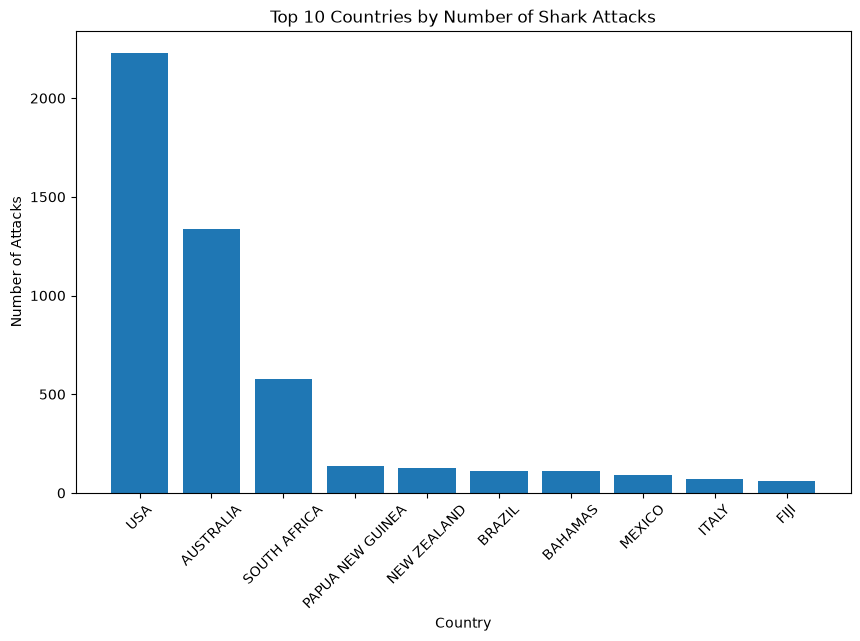

In [9]:
country_attacks = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.bar(country_attacks.index, country_attacks.values)

plt.title("Top 10 Countries by Number of Shark Attacks")
plt.xlabel("Country")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)

plt.show()

In [10]:
df['Fatal (Y/N)'].value_counts()

Fatal (Y/N)
N          4293
Y          1388
UNKNOWN      71
 N            7
M             1
2017          1
N             1
y             1
Name: count, dtype: int64

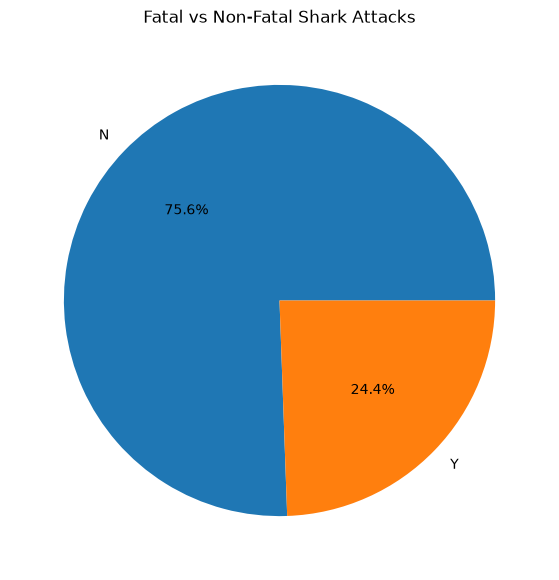

In [11]:
fatal_counts = df['Fatal (Y/N)'].value_counts()

fatal_counts = fatal_counts[fatal_counts.index.isin(['Y', 'N'])]

plt.figure(figsize=(7,7))

plt.pie(
    fatal_counts.values,
    labels=fatal_counts.index,
    autopct='%1.1f%%'
)

plt.title("Fatal vs Non-Fatal Shark Attacks")

plt.show()

In [12]:
age_data = pd.to_numeric(df['Age'], errors='coerce').dropna()

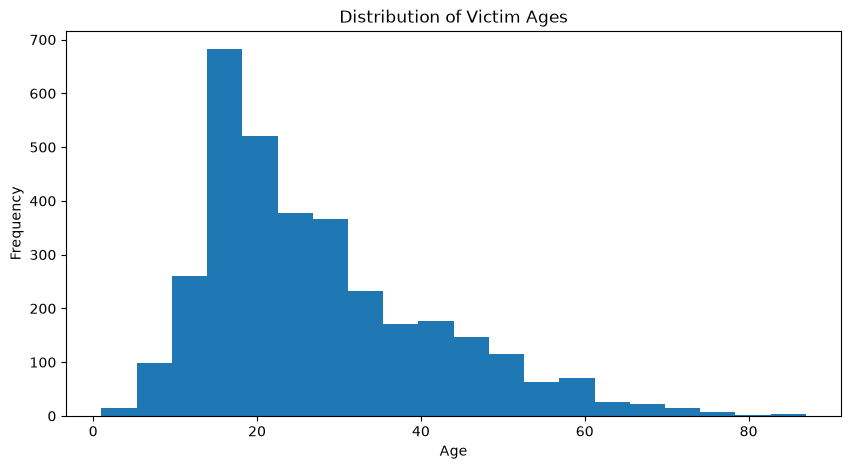

In [13]:
plt.figure(figsize=(10,5))

plt.hist(age_data, bins=20)

plt.title("Distribution of Victim Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [14]:
scatter_data = df[['Year', 'Age']].copy()

scatter_data['Year'] = pd.to_numeric(
    scatter_data['Year'],
    errors='coerce'
)

scatter_data['Age'] = pd.to_numeric(
    scatter_data['Age'],
    errors='coerce'
)

scatter_data = scatter_data.dropna()

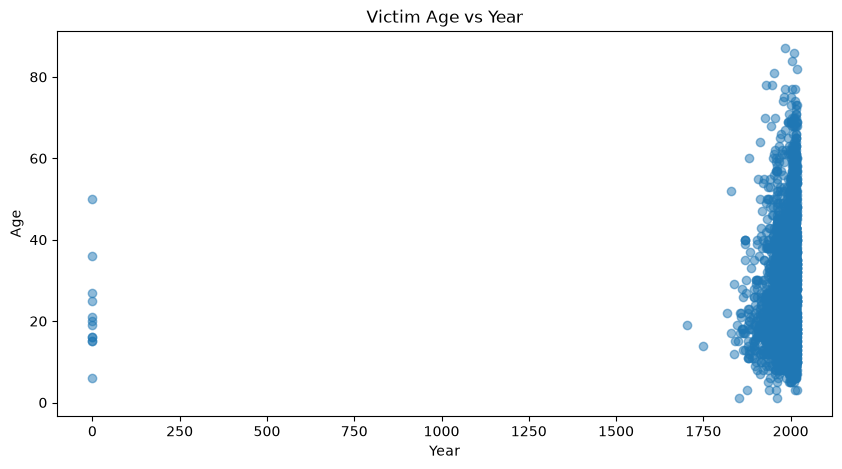

In [15]:
plt.figure(figsize=(10,5))

plt.scatter(
    scatter_data['Year'],
    scatter_data['Age'],
    alpha=0.5
)

plt.title("Victim Age vs Year")
plt.xlabel("Year")
plt.ylabel("Age")

plt.show()

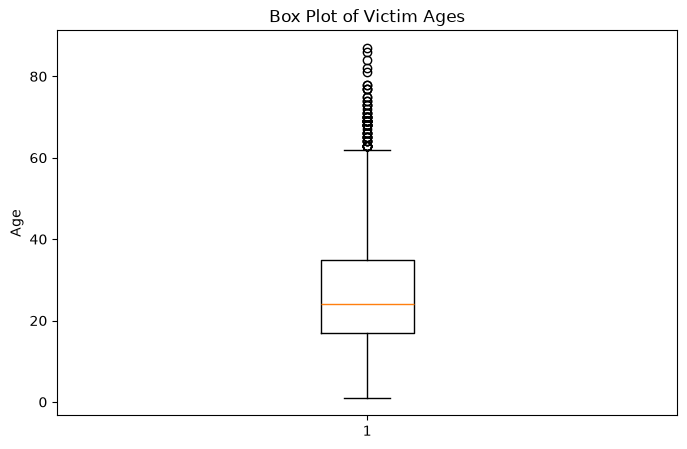

In [16]:
plt.figure(figsize=(8,5))

plt.boxplot(age_data)

plt.title("Box Plot of Victim Ages")
plt.ylabel("Age")

plt.show()